###Data Degraded creation

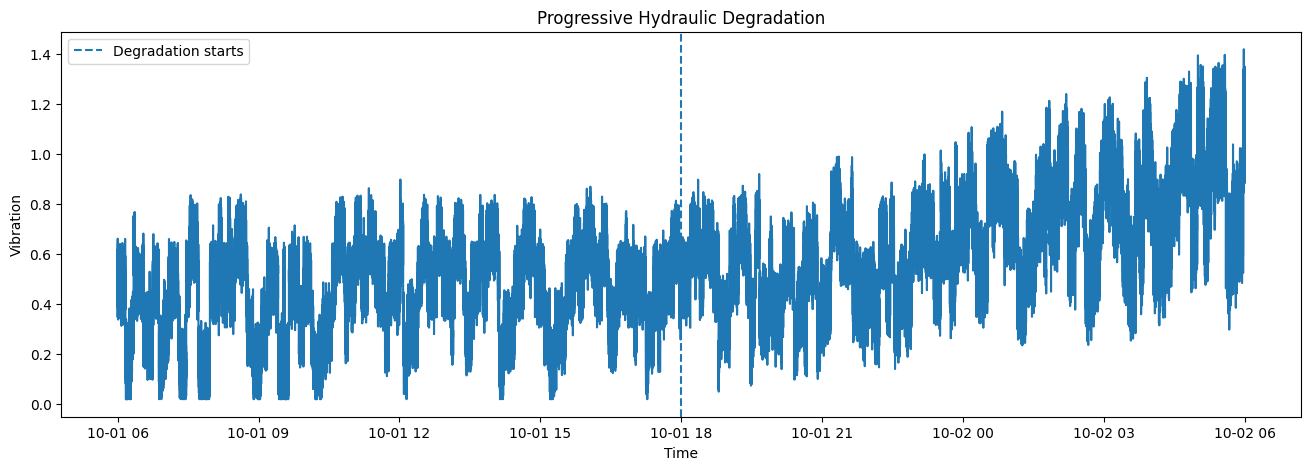

In [5]:
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd


RANDOM_SEED = 42

DB_PATH = Path("/content/machine_telemetry.db")
OUTPUT_DB_PATH = Path("/content/machine_telemetry_degraded.db")


def inject_hydraulic_degradation(df: pd.DataFrame) -> pd.DataFrame:

    rng = np.random.default_rng(RANDOM_SEED)

    df = df.copy()

    start = df["timestamp"].min()
    elapsed_hours = (
        (df["timestamp"] - start)
        .dt.total_seconds()
        / 3600
    )

    # --------------------------------------------------------
    # Degradation factor
    # --------------------------------------------------------

    # 0 until hour 12
    # progressively increases between hour 12 and hour 24

    degradation = np.clip(
        (elapsed_hours - 12) / 12,
        0,
        1
    )

    # --------------------------------------------------------
    # Hydraulic pressure instability
    # --------------------------------------------------------

    pressure_noise = (
        rng.normal(
            0,
            8 + degradation * 20,
            len(df)
        )
    )

    df["hydraulic_pressure"] += (
        pressure_noise * degradation
    )

    # --------------------------------------------------------
    # Hydraulic temperature
    # --------------------------------------------------------

    df["hydraulic_temperature"] += (
        degradation * 15
        + rng.normal(
            0,
            degradation * 1.5,
            len(df)
        )
    )

    # --------------------------------------------------------
    # Vibration
    # --------------------------------------------------------

    df["vibration"] += (
        degradation * 0.45
        + rng.normal(
            0,
            degradation * 0.08,
            len(df)
        )
    )

    # --------------------------------------------------------
    # Fuel inefficiency
    # --------------------------------------------------------

    df["fuel_rate"] += (
        degradation
        * df["engine_load"]
        * 6
    )

    # --------------------------------------------------------
    # Fault state
    # --------------------------------------------------------

    df["machine_condition"] = np.select(
        [
            degradation == 0,
            degradation < 0.33,
            degradation < 0.66,
        ],
        [
            "HEALTHY",
            "EARLY_DEGRADATION",
            "DEGRADATION",
        ],
        default="CRITICAL",
    )

    df["degradation_index"] = degradation

    return df


def main():

    with sqlite3.connect(DB_PATH) as conn:

        df = pd.read_sql_query(
            """
            SELECT *
            FROM machine_telemetry
            """,
            conn,
            parse_dates=["timestamp"],
        )

    df = inject_hydraulic_degradation(df)

    with sqlite3.connect(OUTPUT_DB_PATH) as conn:

        df.to_sql(
            "machine_telemetry",
            conn,
            if_exists="replace",
            index=False,
        )

        conn.execute(
            """
            CREATE INDEX IF NOT EXISTS
            idx_machine_telemetry_timestamp
            ON machine_telemetry(timestamp)
            """
        )

        conn.commit()

    print("Fault scenario generated.")
    print(f"Rows: {len(df):,}")
    print(f"Output: {OUTPUT_DB_PATH}")


if __name__ == "__main__":
    main()

